In [1]:
import numpy as np

In [2]:
import cv2

In [3]:
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline

In [4]:
import os
print("Current working directory:", os.getcwd())

Current working directory: C:\Users\ulise\World_leaders_face_Recognition\model


In [5]:
img = cv2.imread('./test_images/gettyimages-515383714-612x612.jpg')
img.shape

(612, 482, 3)

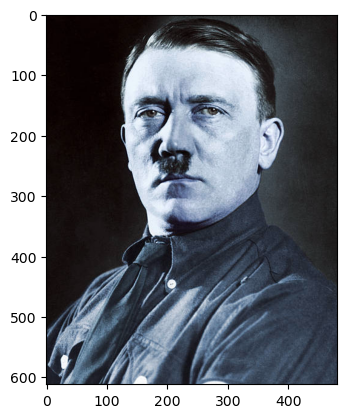

In [6]:
plt.imshow(img)
plt.show()

In [7]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray.shape

(612, 482)

In [8]:
gray

array([[ 7,  6,  6, ..., 21, 23, 23],
       [ 7,  7,  7, ..., 21, 25, 25],
       [ 8,  8,  7, ..., 23, 27, 27],
       ...,
       [34, 34, 34, ..., 54, 58, 64],
       [34, 34, 34, ..., 55, 60, 67],
       [33, 33, 33, ..., 57, 61, 68]], dtype=uint8)

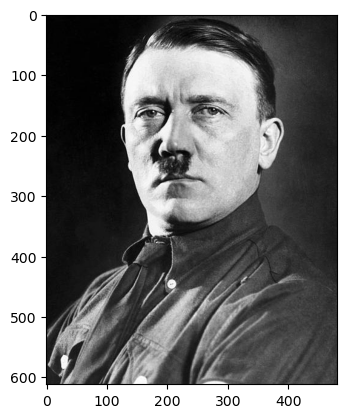

In [9]:
plt.imshow(gray, cmap='gray')
plt.show()

In [10]:
import cv2

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_eye.xml'
)
print(face_cascade.empty())
print(eye_cascade.empty())

False
False


In [11]:
faces = face_cascade.detectMultiScale(gray, 1.3, 5)
faces

array([[ 97,  54, 270, 270]])

In [12]:
(x,y,w,h) = faces[0]
x,y,w,h

(97, 54, 270, 270)

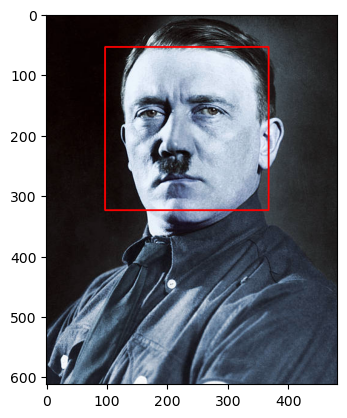

In [13]:
face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
plt.imshow(face_img)
plt.show()

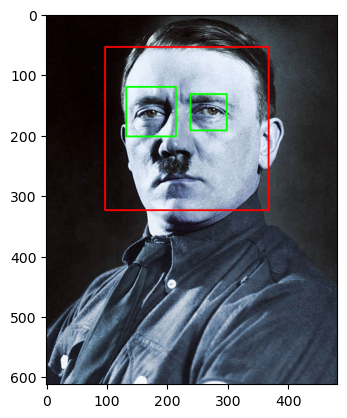

In [14]:
cv2.destroyAllWindows()
for (x,y,w,h) in faces:
    face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = face_img[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)
        

plt.figure()
plt.imshow(face_img, cmap='gray')
plt.show()

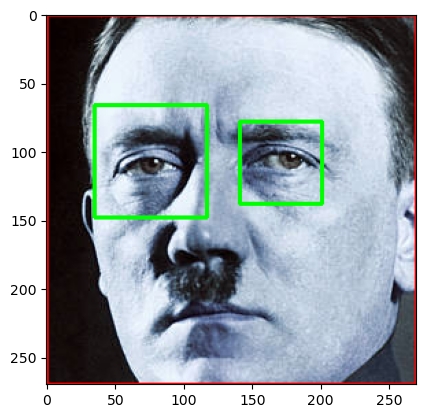

In [15]:
%matplotlib inline
plt.imshow(roi_color, cmap='gray')
plt.show()

In [16]:
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    for (x,y,w,h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes) >= 2:
            return roi_color

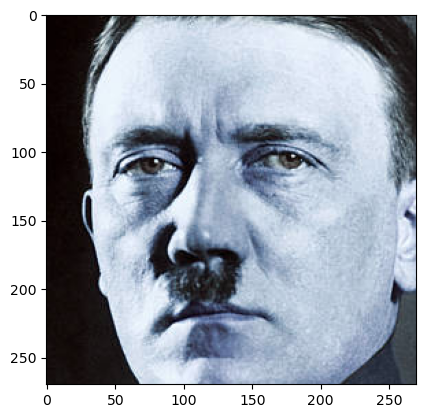

In [17]:
cropped_image = get_cropped_image_if_2_eyes('./test_images/gettyimages-515383714-612x612.jpg')
plt.imshow(cropped_image)
plt.show()

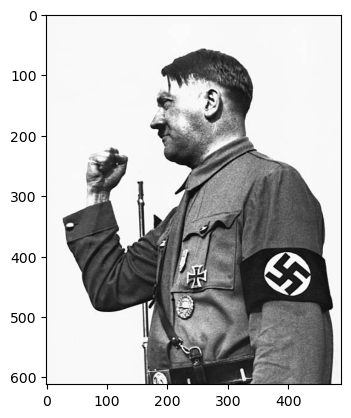

In [18]:
org_image_obstructed = cv2.imread('./test_images/gettyimages-615316426-612x612.jpg')
plt.imshow(org_image_obstructed)
plt.show()

In [19]:
cropped_image_no_2_eyes = get_cropped_image_if_2_eyes('./test_images/gettyimages-615316426-612x612.jpg')
cropped_image_no_2_eyes

In [20]:
path_to_data = "./dataset/"
path_to_cr_data = "./dataset/cropped/"

In [21]:
img_dirs = []
for entry in os.scandir(path_to_data):
    if entry.is_dir():
        img_dirs.append(entry.path)

In [22]:
img_dirs

['./dataset/che_guevara_images',
 './dataset/churchill_images',
 './dataset/hitler_images',
 './dataset/roosevelt_images',
 './dataset/stalin_images']

In [23]:
import shutil
if os.path.exists(path_to_cr_data):
     shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

In [24]:
cropped_image_dirs = []
world_leaders_file_names_dict = {}

for img_dir in img_dirs:
    count = 1
    leader_name = img_dir.split('/')[-1]
    print(leader_name)
    
    world_leaders_file_names_dict[leader_name] = []
    
    for entry in os.scandir(img_dir):
        roi_color = get_cropped_image_if_2_eyes(entry.path)
        if roi_color is not None:
            cropped_folder = path_to_cr_data + leader_name
            if not os.path.exists(cropped_folder):
                os.mkdir(cropped_folder)
                cropped_image_dirs.append(cropped_folder)
                print("Generating cropped images in folder: ",cropped_folder)
                
            cropped_file_name = leader_name + str(count) + ".png"
            cropped_file_path = cropped_folder + "/" + cropped_file_name 
            
            cv2.imwrite(cropped_file_path, roi_color)
            world_leaders_file_names_dict[leader_name].append(cropped_file_path)
            count += 1

che_guevara_images
Generating cropped images in folder:  ./dataset/cropped/che_guevara_images
churchill_images
Generating cropped images in folder:  ./dataset/cropped/churchill_images
hitler_images
Generating cropped images in folder:  ./dataset/cropped/hitler_images
roosevelt_images
Generating cropped images in folder:  ./dataset/cropped/roosevelt_images
stalin_images
Generating cropped images in folder:  ./dataset/cropped/stalin_images


In [25]:
import pywt

In [26]:
def w2d(img, mode='haar', level=1):
    imArray = img
    #Datatype conversions
    #convert to grayscale
    imArray = cv2.cvtColor( imArray,cv2.COLOR_RGB2GRAY )
    #convert to float
    imArray =  np.float32(imArray)   
    imArray /= 255;
    # compute coefficients 
    coeffs=pywt.wavedec2(imArray, mode, level=level)

    #Process Coefficients
    coeffs_H=list(coeffs)  
    coeffs_H[0] *= 0;  

    # reconstruction
    imArray_H=pywt.waverec2(coeffs_H, mode);
    imArray_H *= 255;
    imArray_H =  np.uint8(imArray_H)

    return imArray_H

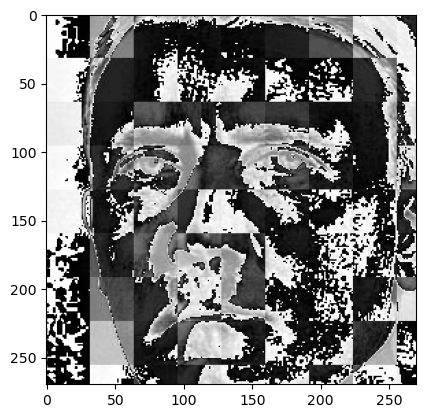

In [27]:
im_har = w2d(cropped_image,'db1',5)
plt.imshow(im_har, cmap='gray')
plt.show()

In [28]:

for img_dir in cropped_image_dirs:
    leader_name = img_dir.split('/')[-1]
    file_list = []
    for entry in os.scandir(img_dir):
        file_list.append(entry.path)
    world_leaders_file_names_dict[leader_name] = file_list
world_leaders_file_names_dict

{'che_guevara_images': ['./dataset/cropped/che_guevara_images\\che_guevara_images1.png',
  './dataset/cropped/che_guevara_images\\che_guevara_images10.png',
  './dataset/cropped/che_guevara_images\\che_guevara_images11.png',
  './dataset/cropped/che_guevara_images\\che_guevara_images12.png',
  './dataset/cropped/che_guevara_images\\che_guevara_images13.png',
  './dataset/cropped/che_guevara_images\\che_guevara_images2.png',
  './dataset/cropped/che_guevara_images\\che_guevara_images3.png',
  './dataset/cropped/che_guevara_images\\che_guevara_images4.png',
  './dataset/cropped/che_guevara_images\\che_guevara_images5.png',
  './dataset/cropped/che_guevara_images\\che_guevara_images6.png',
  './dataset/cropped/che_guevara_images\\che_guevara_images7.png',
  './dataset/cropped/che_guevara_images\\che_guevara_images8.png',
  './dataset/cropped/che_guevara_images\\che_guevara_images9.png'],
 'churchill_images': ['./dataset/cropped/churchill_images\\churchill_images1.png',
  './dataset/croppe

In [29]:
class_dict = {}
count = 0
for leader_name in world_leaders_file_names_dict.keys():
    class_dict[leader_name] = count
    count = count + 1
class_dict

{'che_guevara_images': 0,
 'churchill_images': 1,
 'hitler_images': 2,
 'roosevelt_images': 3,
 'stalin_images': 4}

In [30]:
X, y = [], []
for leader_name, training_files in world_leaders_file_names_dict.items():
    for training_image in training_files:
        img = cv2.imread(training_image)
        scalled_raw_img = cv2.resize(img, (32, 32))
        img_har = w2d(img,'db1',5)
        scalled_img_har = cv2.resize(img_har, (32, 32))
        combined_img = np.vstack((scalled_raw_img.reshape(32*32*3,1),scalled_img_har.reshape(32*32,1)))
        X.append(combined_img)
        y.append(class_dict[leader_name])     

In [31]:
len(X[0])

4096

In [32]:
y[0]

0

In [33]:
X = np.array(X).reshape(len(X),4096).astype(float)
X.shape

(56, 4096)

In [34]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel = 'rbf', C = 10))])
pipe.fit(X_train, y_train)
pipe.score(X_test, y_test)

0.5714285714285714

In [36]:
print(classification_report(y_test, pipe.predict(X_test)))

              precision    recall  f1-score   support

           0       0.67      0.50      0.57         4
           1       1.00      0.50      0.67         2
           2       0.00      0.00      0.00         1
           3       0.56      1.00      0.71         5
           4       0.00      0.00      0.00         2

    accuracy                           0.57        14
   macro avg       0.44      0.40      0.39        14
weighted avg       0.53      0.57      0.51        14



C:\Users\ulise\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ulise\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ulise\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [37]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

In [38]:
model_params = {
    'svm': {
        'model': svm.SVC(gamma='auto',probability=True),
        'params' : {
            'svc__C': [1,10,100,1000],
            'svc__kernel': ['rbf','linear']
        }  
    },
    'random_forest': {
        'model': RandomForestClassifier(),
        'params' : {
            'randomforestclassifier__n_estimators': [1,5,10]
        }
    },
    'logistic_regression' : {
        'model': LogisticRegression(solver='liblinear',multi_class='auto'),
        'params': {
            'logisticregression__C': [1,5,10]
        }
    }
}

In [39]:
scores = []
best_estimators = {}
import pandas as pd
for algo, mp in model_params.items():
    pipe = make_pipeline(StandardScaler(), mp['model'])
    clf =  GridSearchCV(pipe, mp['params'], cv=5, return_train_score=False)
    clf.fit(X_train, y_train)
    scores.append({
        'model': algo,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })
    best_estimators[algo] = clf.best_estimator_
    
df = pd.DataFrame(scores,columns=['model','best_score','best_params'])
df

C:\Users\ulise\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ulise\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ulise\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ulise\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in versio

,model,best_score,best_params
0,svm,0.480556,"{'svc__C': 1, 'svc__kernel': 'linear'}"
1,random_forest,0.388889,{'randomforestclassifier__n_estimators': 10}
2,logistic_regression,0.547222,{'logisticregression__C': 1}


In [40]:
best_estimators

{'svm': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('svc',
                  SVC(C=1, gamma='auto', kernel='linear', probability=True))]),
 'random_forest': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('randomforestclassifier',
                  RandomForestClassifier(n_estimators=10))]),
 'logistic_regression': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('logisticregression',
                  LogisticRegression(C=1, multi_class='auto',
                                     solver='liblinear'))])}

In [41]:
best_estimators['svm'].score(X_test,y_test)

0.5

In [42]:
best_estimators['random_forest'].score(X_test,y_test)

0.14285714285714285

In [43]:
best_estimators['logistic_regression'].score(X_test,y_test)

0.6428571428571429

In [50]:
best_clf = best_estimators['logistic_regression']

In [51]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, best_clf.predict(X_test))
cm

array([[3, 0, 1, 0, 0],
       [0, 2, 0, 0, 0],
       [0, 0, 0, 1, 0],
       [0, 1, 1, 3, 0],
       [0, 0, 1, 0, 1]], dtype=int64)

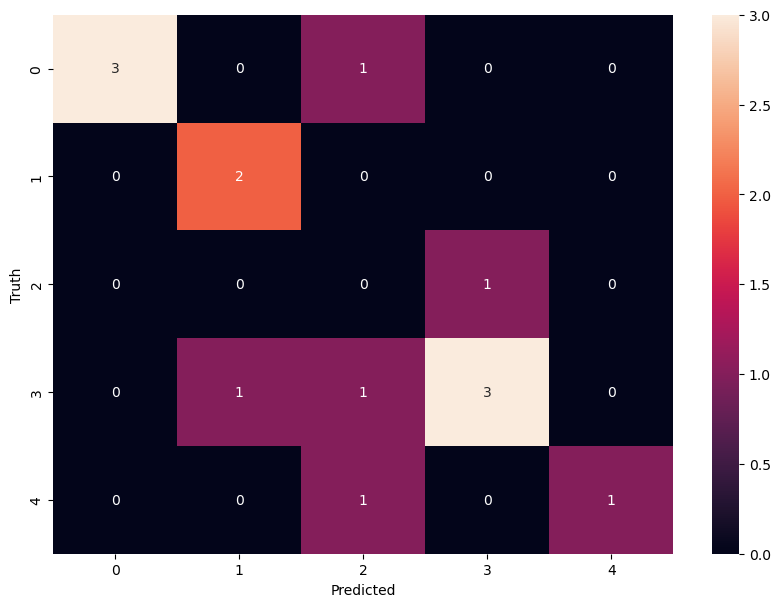

In [52]:
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

In [47]:
import joblib

In [48]:
joblib.dump(best_clf, 'saved_model.pkl')

['saved_model.pkl']

In [49]:
import json
with open("class_dictionary.json","w") as f:
    f.write(json.dumps(class_dict))